# Experiments vs simulations: Quads design (3dp pla + blue shims) for static cloaking of a smile-shaped void

## Imports

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
from typing import Union
from mechanicalmetamaterialcloaks.plotting import generate_animation
from mechanicalmetamaterialcloaks.utils import save_data, load_data, SolutionData
from problems.quads_static_cloaking import OptimizationProblem
from mechanicalmetamaterialcloaks.plotting import plot_video_frame_field_overlaid, plot_geometry_field_overlaid
from scipy import interpolate
import tqdm

from pathlib import Path
import pandas as pd
from scripts.tracking.utils import smooth_fields_SG
import jax.numpy as jnp
from jax import random
import jax
jax.config.update("jax_enable_x64", True)  # enable float64 type

plt.style.use(["science", "grid"])
%matplotlib widget

## Paths

In [17]:
# Where to load/save data
data_folder = Path("../../../data/quads_static_cloaking_3dp_pla_shims")
data_folder_reference_compressed = Path("../../../data/quads_static_cloaking_3dp_pla_shims_reference_compressed")
# Where to save plots and animations
out_folder = Path("../../../out/quads_static_cloaking_3dp_pla_shims")

## Problem info

NOTE: Either define the problem info here or load it from an optimization file.

In [3]:
# NOTE: Units are mm, N, s

# Retrieve design info from optimization data
optimization_filename = f"opt_integrated_with_angle_30_and_length_3_constraints_quads_15x15_amplitude_15.0_initial_angle_20.0_void_big_smile"
optimization = OptimizationProblem.from_dict(
    load_data(
        f"{data_folder}/{optimization_filename}.pkl",
    )
)
problem = optimization.forward_problem
# Set up the forward problem to get the geometry
problem.setup()
geometry = problem.cloaked_geometry

# Select the best design
design_values = optimization.design_values[-1]

Setup solver of the intact geometry
Compute dynamics of the intact geometry
Setup solver of the voided geometry
Initialization done


## Experimental video paths


In [4]:
# Subfolder for videos and tracking data
design_name = optimization_filename

# Experimental videos to be processed - Reference design
video_paths_reference = sorted(
    list(Path(f"{data_folder_reference_compressed}/videos").glob("*.mp4"))
)
# Experimental videos to be processed - Cloaked design
video_paths_holed = sorted(
    list(Path(f"{data_folder}/{design_name}/videos").glob("holed_*.mp4"))
)
# Experimental videos to be processed - Cloaked design
video_paths_cloaked = sorted(
    list(Path(f"{data_folder}/{design_name}/videos").glob("cloaked_*.mp4"))
)
video_paths = video_paths_reference + video_paths_holed + video_paths_cloaked

## Load tracking data


### Reference compressed design

In [5]:
# Find all data files in the dynamic-data folder
tracked_data_paths_reference = sorted(list(Path(
    f"{data_folder_reference_compressed}/dynamic-data/tracking_exp/").glob("*.pkl")))

# Load the tracked data as a dataframe
tracked_data_reference = pd.DataFrame({
    "label": [p.stem for p in tracked_data_paths_reference],
    "video_path": video_paths_reference,
    "data": [SolutionData(**load_data(p)) for p in tracked_data_paths_reference],
})

# Smooth tracking data
tracked_data_reference.data = tracked_data_reference.apply(
    lambda row: row.data._replace(fields=smooth_fields_SG(
        row.data.fields, window_length=[[7, 7, 20], [7, 7, 20]], polyorder=2)),
    axis=1,
)


### Holed design

In [6]:
# Find all data files in the dynamic-data folder
tracked_data_paths = sorted(list(Path(f"{data_folder}/{design_name}/dynamic-data/tracking_exp/").glob("holed_*.pkl")))

# Load the tracked data as a dataframe
tracked_data_holed = pd.DataFrame({
    "label": [p.stem for p in tracked_data_paths],
    "video_path": video_paths_holed,
    "data": [SolutionData(**load_data(p)) for p in tracked_data_paths],
})

# Smooth tracking data
tracked_data_holed.data = tracked_data_holed.apply(
    lambda row: row.data._replace(fields=smooth_fields_SG(
        row.data.fields, window_length=[[10, 10, 25], [10, 10, 25]], polyorder=2)),
    axis=1,
)

### Cloaked design

In [7]:
# Find all data files in the dynamic-data folder
tracked_data_paths = sorted(list(Path(f"{data_folder}/{design_name}/dynamic-data/tracking_exp/").glob("cloaked_*.pkl")))

# Load the tracked data as a dataframe
tracked_data_cloaked = pd.DataFrame({
    "label": [p.stem for p in tracked_data_paths],
    "video_path": video_paths_cloaked,
    "data": [SolutionData(**load_data(p)) for p in tracked_data_paths],
})

# Smooth tracking data
tracked_data_cloaked.data = tracked_data_cloaked.apply(
    lambda row: row.data._replace(fields=smooth_fields_SG(
        row.data.fields, window_length=[[10, 10, 25], [10, 10, 25]], polyorder=2)),
    axis=1,
)

### Concatenate dataframes

In [8]:
tracked_data = pd.concat([tracked_data_reference, tracked_data_holed, tracked_data_cloaked], ignore_index=True)
tracked_data

,label,video_path,data
0,reference_compressed,../../../data/quads_static_cloaking_3dp_pla_sh...,"([[15.0, 0.0], [30.086111807800044, 0.41766143..."
1,holed_compressed,../../../data/quads_static_cloaking_3dp_pla_sh...,"([[15.0, 0.0], [29.553516937016227, -0.2486934..."
2,cloaked_compressed,../../../data/quads_static_cloaking_3dp_pla_sh...,"([[15.0, 0.0], [29.471952471679693, -0.4812618..."


## Plot deformation fields

### Helper functions

In [10]:
def scaled_to_unscaled_idx(x, array):
    """Return the index in the unscaled array corresponding to the scaled index x."""
    return int(x * (len(array) - 1))

In [11]:
def plot_snapshot_experiment(
        df_row: pd.Series,
        field: str,
        time: float,
        cmap="inferno",
        alpha_overlay=0.8,
        vlim=None,
        figsize=(4, 4),
        ax=None,):
    """Plot a snapshot of the experiment."""

    vmin, vmax = vlim if vlim is not None else (None, None)
    timepoint = scaled_to_unscaled_idx(time, df_row.data.timepoints)
    fig, axes = plot_video_frame_field_overlaid(
        video_filename=df_row.video_path,
        solution_data=df_row.data,
        field=field,
        frame_number=df_row.frame_start+timepoint*df_row.step_size,
        timepoint=timepoint,
        calib_xy=df_row.calib_xy,
        ROI_X=df_row.ROI_X,
        ROI_Y=df_row.ROI_Y,
        shift_px=df_row.shift_px,
        alpha_overlay=alpha_overlay,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        figsize=figsize,
        ax=ax,
    )
    return fig, axes


def plot_snapshot_simulation(
        solution_data: SolutionData,
        field: str,
        time: float,
        cmap="inferno",
        figsize=(4, 4),
        xlim=None,
        ylim=None,
        vlim=None,
        ax=None,):
    """Plot a snapshot of the simulation."""

    timepoint = scaled_to_unscaled_idx(time, solution_data.timepoints)
    fig, axes = plot_geometry_field_overlaid(
        data=solution_data,
        field=field,
        timepoint=timepoint,
        deformed=True,
        cmap=cmap,
        xlim=xlim,
        ylim=ylim,
        vlim=vlim,
        colorbar=False,
        figsize=figsize,
        axis=False,
        ax=ax,
    )
    return fig, axes


def resample_simulation_data(data: SolutionData, n_samples: int = 400):
    """Resample simulation data to match the experimental data (i.e. linear loading/unloading ramp)."""
    normalized_applied_displacement = problem.applied_displacement(
        data.timepoints/data.timepoints[-1], 1., 1.)
    interpolated_fields_loading = interpolate.make_interp_spline(
        x=0.5*normalized_applied_displacement,
        y=data.fields,
        k=3,
        axis=0,
    )

    def interpolated_fields_loading_unloading(t):
        return interpolated_fields_loading(-jnp.abs(t-0.5)+0.5)

    normalized_timepoints = jnp.linspace(0, 1, n_samples)
    return data._replace(
        fields=interpolated_fields_loading_unloading(
            normalized_timepoints
        ),
        timepoints=normalized_timepoints,
    )

### Experiments

In [9]:
# Plotting parameters for each experiment i.e. each row of the tracked_data dataframe
plot_params = dict(
    calib_xy=[(0.268, 0.268), (15*14/573, 15*14/573), (15*14/566, 15*14/566)],
    ROI_X=[(50, 1050), (155, 950-55-5), (155+20, 950-55-5)],
    ROI_Y=[(440+10, 1370-10), (580+10+10, 1320-40-10), (580+25+2, 1320-55-6)],
    shift_px=[(105, 60), (83, 50), (78, 40)],
    frame_start=[400, 240, 120],
    step_size=[35, 90, 90],
)
# Add plot params to the tracked_data dataframe
for key, value in plot_params.items():
    tracked_data[key] = value
tracked_data

,label,video_path,data,calib_xy,ROI_X,ROI_Y,shift_px,frame_start,step_size
0,reference_compressed,../../../data/quads_static_cloaking_3dp_pla_sh...,"([[15.0, 0.0], [30.086111807800044, 0.41766143...","(0.268, 0.268)","(50, 1050)","(450, 1360)","(105, 60)",400,35
1,holed_compressed,../../../data/quads_static_cloaking_3dp_pla_sh...,"([[15.0, 0.0], [29.553516937016227, -0.2486934...","(0.36649214659685864, 0.36649214659685864)","(155, 890)","(600, 1270)","(83, 50)",240,90
2,cloaked_compressed,../../../data/quads_static_cloaking_3dp_pla_sh...,"([[15.0, 0.0], [29.471952471679693, -0.4812618...","(0.3710247349823322, 0.3710247349823322)","(175, 890)","(607, 1259)","(78, 40)",120,90


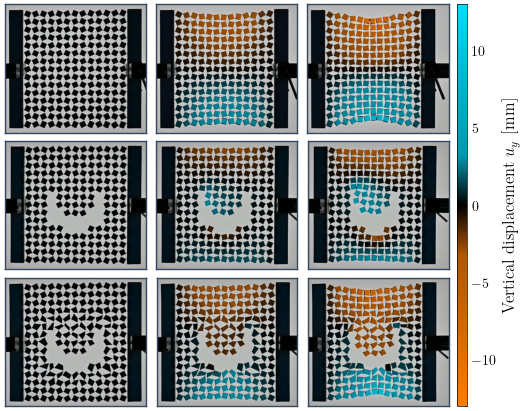

In [ ]:
normalized_timepoints = jnp.array([0., 0.5, 1.])/2

cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    name="custom_cmap",
    colors=[
        "#ff7b00",  # negative
        "#e46e00",  # negative
        "#c86100",  # negative
        "#b25600",  # negative
        "#000000",  # 0
        "#0098b0",  # positive
        "#00aac4",  # positive
        "#00c1df",  # positive
        "#00ddff",  # positive
    ],
)
vlim = (
    -13.,  # tracked_data.data.apply(lambda x: x.fields[:, 0, :, 1].min()).min(),
    13.,  # tracked_data.data.apply(lambda x: x.fields[:, 0, :, 1].max()).max(),
)
plt.close("all")
fig, axes = plt.subplots(ncols=len(normalized_timepoints),
                         nrows=tracked_data.shape[0], figsize=(1.75*3, 4.1), constrained_layout=True)
for i, row in tracked_data.iterrows():
    for j, time in enumerate(normalized_timepoints):
        plot_snapshot_experiment(df_row=row, field="uy", cmap=cmap, time=time, ax=axes[i, j], vlim=vlim)
        axes[i, j].axis("on")
        # Remove x and y ticks
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
        for spine in axes[i, j].spines.values():
            spine.set_linewidth(1)
            spine.set_color("#34495e")

# Add colorbar
norm = plt.Normalize(vmin=vlim[0], vmax=vlim[1])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cb = fig.colorbar(sm, ax=axes, location="right", aspect=40, pad=0.02)
cb.ax.tick_params(labelsize=10)
cb.set_label(r"Vertical displacement $u_y$ [mm]", fontsize=12)
# Save the figure
out_path = out_folder / design_name / f"snapshots_experiment_reference_holed_cloaked_uy.png"
out_folder.mkdir(parents=True, exist_ok=True)
fig.savefig(str(out_path), dpi=300, bbox_inches="tight")

### Simulations

In [13]:
simulation_datas = problem.solution_data
simulation_data_resampled = [
    resample_simulation_data(data)
    for data in simulation_datas
]

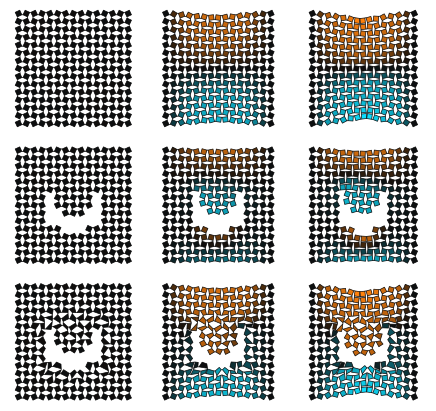

In [18]:
normalized_timepoints = jnp.array([0., 0.6, 1.])/2

cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    name="custom_cmap",
    colors=[
        "#ff7b00",  # negative
        "#e46e00",  # negative
        "#c86100",  # negative
        "#b25600",  # negative
        "#000000",  # 0
        "#0098b0",  # positive
        "#00aac4",  # positive
        "#00c1df",  # positive
        "#00ddff",  # positive
    ],
)
vlim = (
    -13.,  # tracked_data.data.apply(lambda x: x.fields[:, 0, :, 1].min()).min(),
    13.,  # tracked_data.data.apply(lambda x: x.fields[:, 0, :, 1].max()).max(),
)
xlim, ylim = geometry.get_xy_limits(*problem.cloak_to_all_shifts(design_values)) + 1*jnp.array([[-0.5, 0.5],[-0.5, 0.5]])*problem.spacing
plt.close("all")
fig, axes = plt.subplots(ncols=len(normalized_timepoints), nrows=len(simulation_data_resampled), figsize=(1.45*3, 4.1), constrained_layout=True)
for i, simulation_data in enumerate(simulation_data_resampled):
    for j, time in enumerate(normalized_timepoints):
        plot_snapshot_simulation(
            solution_data=simulation_data,
            field="uy",
            time=time,
            cmap=cmap,
            xlim=xlim,
            ylim=ylim,
            vlim=vlim,
            ax=axes[i, j],
        )
        axes[i, j].axis("equal")
# # Add colorbar
# cmap = plt.cm.inferno
# norm = plt.Normalize(vmin=vlim[0], vmax=vlim[1])
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# Save the figure
out_path = out_folder / design_name / f"snapshots_simulation_reference_holed_cloaked_uy.png"
out_folder.mkdir(parents=True, exist_ok=True)
fig.savefig(str(out_path), dpi=300, bbox_inches="tight")


### Experiments vs simulations

In [ ]:
plt.close("all")
xlim, ylim = geometry.get_xy_limits(*problem.cloak_to_all_shifts(design_values)) + jnp.array([[-3.5, 3.5],[-3.5, 3.5]])*problem.spacing
fig, axes = plt.subplots(ncols=len(normalized_timepoints), nrows=tracked_data.shape[0]*2, figsize=(2*4, 1.9*4), constrained_layout=True)
for i, row in tracked_data.iterrows():
    for j, time in enumerate(normalized_timepoints):
        plot_snapshot_experiment(
            df_row=row,
            field="theta",
            cmap="coolwarm",
            time=time,
            vlim=(0, 0.4),
            ax=axes[i, j],
        )
        plot_snapshot_simulation(
            solution_data=simulation_data_resampled[i],
            field="theta",
            cmap="coolwarm",
            time=time,
            xlim=xlim,
            ylim=ylim,
            vlim=(0, 0.4),
            ax=axes[2+i, j],
        )
        axes[i, j].axis("equal")
        axes[2+i, j].axis("equal")

In [ ]:
def perturb_array(array, key, noise_amplitude=0.1):
    return array + random.uniform(random.PRNGKey(key), array.shape, minval=-1, maxval=1)*noise_amplitude


def perturb_design_value(design_value, key, noise_amplitude=0.1):
    return (perturb_array(design_value[0], key, noise_amplitude),
            perturb_array(design_value[1], key+1, noise_amplitude))

key = 2
noise_amplitude = 0.03

solution_data_perturbed = optimization.forward_problem.solve_all_shifts(
    perturb_design_value(
        optimization.forward_problem.cloak_to_all_shifts(
            design_values
        ),
        key,
        noise_amplitude*optimization.forward_problem.spacing,
    )
)

In [ ]:
simulation_datas = [problem.solution_data[1], solution_data_perturbed]
simulation_data_resampled = [
    resample_simulation_data(data)
    for data in simulation_datas
]

### Export all experimental frames: Reference vs holed vs cloaked

In [ ]:
plt.ioff()
plt.close("all")
xlim, ylim = geometry.get_xy_limits(*problem.cloak_to_all_shifts(design_values)) + \
    jnp.array([[-3.5, 3.5], [-3.5, 3.5]])*problem.spacing
fig, axes = plt.subplots(ncols=3, figsize=(3*4, 4), constrained_layout=True)

normalized_timepoints = jnp.linspace(0, 1., 200)
field = "uy"
cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    name="custom_cmap",
    colors=[
        "#ff7b00",  # negative
        "#e46e00",  # negative
        "#c86100",  # negative
        "#b25600",  # negative
        "#000000",  # 0
        "#0098b0",  # positive
        "#00aac4",  # positive
        "#00c1df",  # positive
        "#00ddff",  # positive
    ],
)
vlim = (-14.5, 14.5)

for t, time in enumerate(tqdm.tqdm(normalized_timepoints, desc="Exporting frames")):
    for i, row in tracked_data.iterrows():
        plot_snapshot_experiment(
            df_row=row,
            field=field,
            cmap=cmap,
            time=time,
            vlim=vlim,
            ax=axes[i],
        )
    # Set all axis to be equal
    for ax in axes.flatten():
        ax.axis("equal")
    # Save figure
    out_path = out_folder / optimization_filename / "exp_reference_holed_cloaked_frames" / f"frame_{t:03d}.png"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(str(out_path), dpi=300)
    for ax in axes.flatten():
        ax.clear()
plt.ion()

# # Export colorbar
# fig, ax = plt.subplots(figsize=(0.2, 5))
# cmap = plt.cm.coolwarm
# norm = plt.Normalize(vmin=vlim[0], vmax=vlim[1])
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# cbar = fig.colorbar(sm, cax=ax, orientation='vertical', label=r'Displacement $u_y$ [mm]')
# cbar.ax.yaxis.label.set_size(18)
# cbar.ax.tick_params(labelsize=16)
# fig.savefig(out_folder / optimization_filename / "colorbar.png", dpi=300, bbox_inches='tight')
# plt.close(fig)